In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.distributions.empirical_distribution import ECDF
import math
import scipy.stats
import warnings
from scipy.stats import norm
warnings.filterwarnings("ignore")
pd.options.display.float_format = '{:.3f}'.format

# 데이터 불러오기
original = pd.read_csv('c:\python\data2(filtered).csv', dtype={2: 'str'}).iloc[:,2:7]

original = original.reset_index(drop = True)
# 신고중량이 0으로 신고된 수입건 제외
original = original.drop(original[original['신고중량'] == 0].index)
# 1년간 수입한 일수가 100일 미만은 품목 제외
#year_ago = original['수리일자'].max() - 10000
#hs_hole = list(original[original['수리일자'] > year_ago]['HS10단위부호'].value_counts()[original[original['수리일자'] > year_ago]['HS10단위부호'].value_counts() < 100].index)
#original = original[~original['HS10단위부호'].isin(hs_hole)]

# 연도_주차 구하기
original['수리일자'] = original['수리일자'].astype(str)
original['수리일자'] = pd.to_datetime(original['수리일자'])
original['연도'] = original['수리일자'].dt.year
original['월'] = original['수리일자'].dt.month
original['주차'] = original['수리일자'].dt.isocalendar().week
original['연도주차'] = original['연도'] * 100 + original['주차']
original['연도주차'][(original['월'] == 1) & (original['주차'] > 5)] -= 100
original['연도주차'][(original['월'] == 12) & (original['주차'] < 5)] += 100
original['연도주차'] = original['연도주차'].apply(lambda x : str(x)[2:4] + '_' + str(x)[4:])

# 전체 연도_주차 데이터 생성
date_index = original['연도주차'].unique()
# 사용하는 컬럼 정리
use_col = ['HS10단위부호', '연도주차', '무역거래처국가코드', '신고중량', '과세가격미화금액']

p_eriod = -52


HS Code : 3102109000
      연도주차    단가         신고중량
0    17_04 0.255  5332959.546
1    17_05 0.262  6013912.829
2    17_06 0.266  5785572.955
3    17_07 0.274  6293268.930
4    17_08 0.273  5994605.184
..     ...   ...          ...
292  22_34 0.685 15555657.293
293  22_35 0.675 15785998.656
294  22_36 0.667 13272932.558
295  22_37 0.668 13644743.548
296  22_38 0.678  8370437.638

[297 rows x 3 columns]
21_40주차
21_39주차
21_38주차
21_37주차
21_36주차
21_35주차
21_34주차
21_33주차


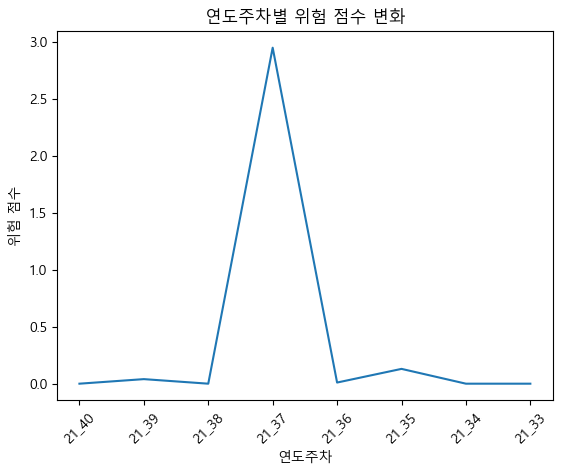

HS Code : 3707901010
      연도주차      단가      신고중량
0    17_04 219.044 17693.709
1    17_05 213.153 21010.400
2    17_06 216.113 19536.734
3    17_07 227.025 18619.221
4    17_08 223.977 18453.471
..     ...     ...       ...
292  22_34 414.585 19852.651
293  22_35 379.294 22915.441
294  22_36 378.936 22876.105
295  22_37 377.473 23998.908
296  22_38 338.724 23399.665

[297 rows x 3 columns]
19_30주차
19_29주차
19_28주차
19_27주차
19_26주차
19_25주차
19_24주차
19_23주차


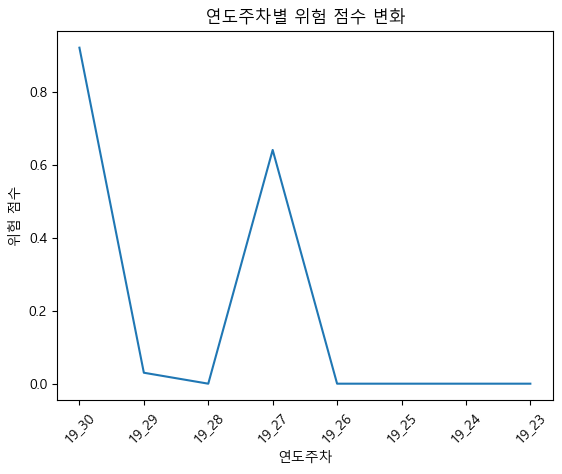

HS Code : 4407191000
      연도주차    단가       신고중량
0    17_04 1.321 239293.247
1    17_05 1.320 250460.747
2    17_06 1.335 267243.948
3    17_07 1.353 205743.000
4    17_08 1.355 166353.875
..     ...   ...        ...
292  22_34 1.459  46860.691
293  22_35 1.597  55567.169
294  22_36 1.587  60067.169
295  22_37 1.328  54362.169
296  22_38 1.313  49607.857

[297 rows x 3 columns]
21_14주차
21_13주차
21_12주차
21_11주차
21_10주차
21_09주차
21_08주차
21_07주차


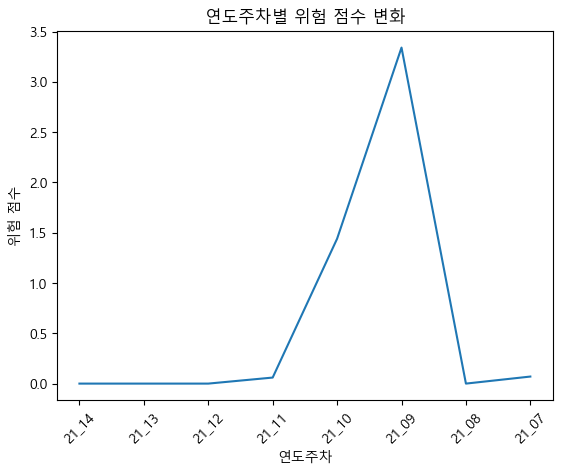

HS Code : 8111000000
      연도주차    단가        신고중량
0    17_04 2.294 1589538.823
1    17_05 2.322 1797062.025
2    17_06 2.349 2135029.125
3    17_07 2.255 2589847.688
4    17_08 2.222 2647460.135
..     ...   ...         ...
292  22_34 2.417 1887338.301
293  22_35 2.470 1322372.493
294  22_36 2.402 1172857.531
295  22_37 2.328 1437803.669
296  22_38 2.315  991759.689

[297 rows x 3 columns]
21_45주차
21_44주차
21_43주차
21_42주차
21_41주차
21_40주차
21_39주차
21_38주차


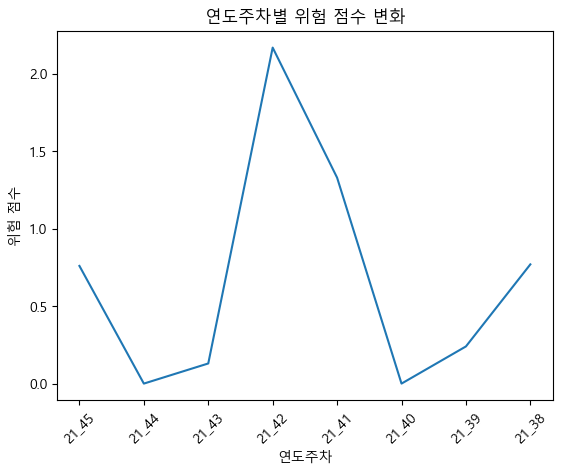

HS Code : 2701129010
      연도주차    단가          신고중량
0    17_04 0.177 163414532.500
1    17_05 0.183 128339537.000
2    17_06 0.187  77542167.000
3    17_07 0.178  87019096.075
4    17_08 0.165 107989167.275
..     ...   ...           ...
292  22_34 0.285 145518255.411
293  22_35 0.274 197342702.911
294  22_36 0.280 214007115.594
295  22_37 0.268 198569715.141
296  22_38 0.273 160074550.041

[297 rows x 3 columns]
21_51주차
21_50주차
21_49주차
21_48주차
21_47주차
21_46주차
21_45주차
21_44주차


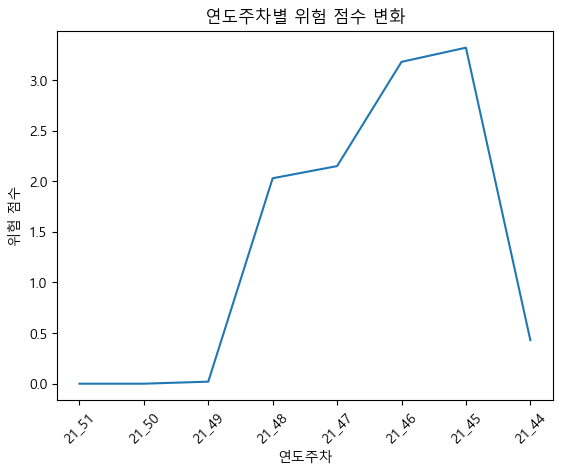

HS Code : 2804701000
      연도주차    단가       신고중량
0    17_04 2.811 160032.550
1    17_05 2.856 164322.550
2    17_06 2.862 142277.500
3    17_07 2.849 143690.000
4    17_08 2.827 128430.000
..     ...   ...        ...
292  22_34 7.502 144652.712
293  22_35 7.193 160465.212
294  22_36 7.270 198465.212
295  22_37 7.206 209505.000
296  22_38 7.230 164662.500

[297 rows x 3 columns]
21_51주차
21_50주차
21_49주차
21_48주차
21_47주차
21_46주차
21_45주차
21_44주차


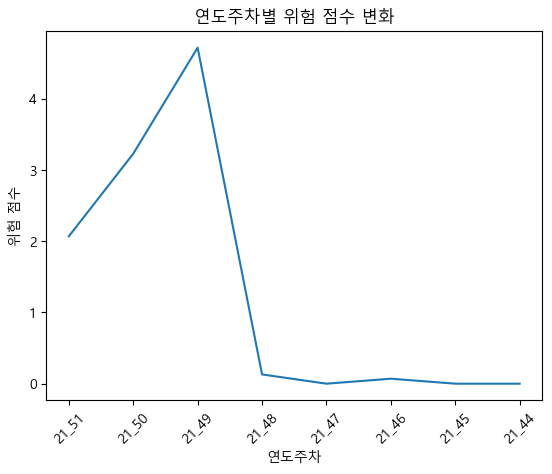

HS Code : 1511901000
      연도주차    단가        신고중량
0    17_04 0.735  936849.355
1    17_05 0.734  930738.055
2    17_06 0.754  893311.305
3    17_07 0.756 1637404.305
4    17_08 0.774 1212247.700
..     ...   ...         ...
292  22_34 1.468  759382.356
293  22_35 1.501  785201.626
294  22_36 1.488  774298.645
295  22_37 1.569  271958.020
296  22_38 1.391  698774.770

[297 rows x 3 columns]
22_02주차
22_01주차
21_53주차
21_52주차
21_51주차
21_50주차
21_49주차
21_48주차


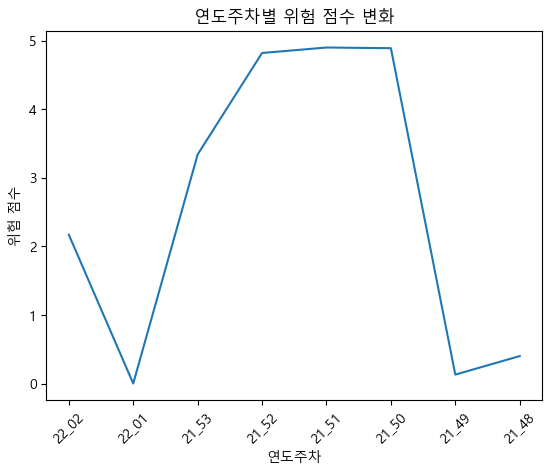

HS Code : 305531000
      연도주차     단가       신고중량
0    17_04 10.143 112739.000
1    17_05 10.020 106671.250
2    17_06  9.953 107973.500
3    17_07  9.665  98612.500
4    17_08  9.570  93437.500
..     ...    ...        ...
292  22_34 10.917 132790.114
293  22_35 10.543 146227.391
294  22_36 10.839 132587.659
295  22_37 10.828 108393.587
296  22_38 10.431  98649.147

[297 rows x 3 columns]
22_07주차
22_06주차
22_05주차
22_04주차
22_03주차
22_02주차
22_01주차
21_53주차


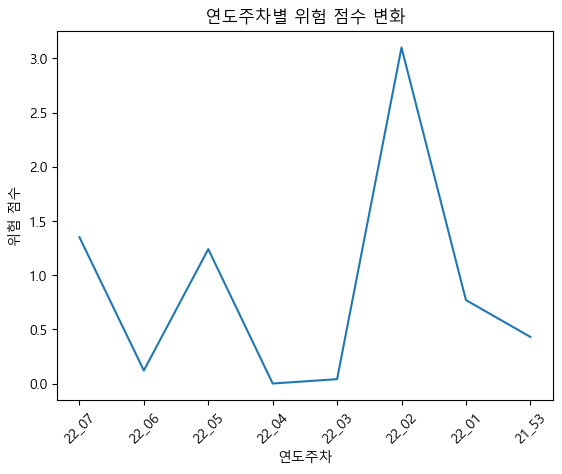

HS Code : 302140000
      연도주차     단가       신고중량
0    17_04 12.297 248997.765
1    17_05 11.776 247770.110
2    17_06 11.204 258943.758
3    17_07 10.781 262438.498
4    17_08 10.400 279016.205
..     ...    ...        ...
292  22_34 13.914 361472.777
293  22_35 13.643 378891.888
294  22_36 13.112 381338.341
295  22_37 12.738 381753.838
296  22_38 12.394 386434.054

[297 rows x 3 columns]
22_08주차
22_07주차
22_06주차
22_05주차
22_04주차
22_03주차
22_02주차
22_01주차


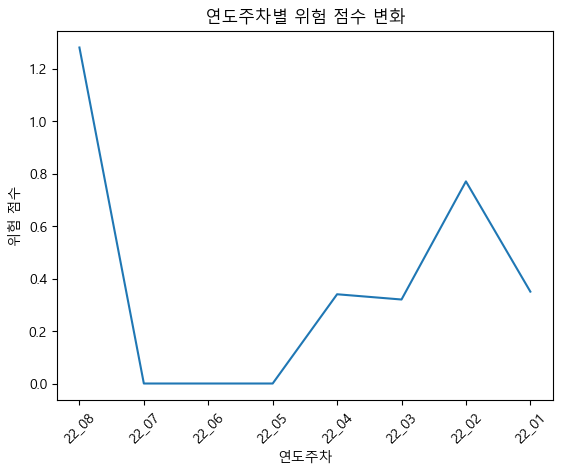

HS Code : 1003901000
      연도주차    단가        신고중량
0    17_04   NaN         NaN
1    17_05   NaN         NaN
2    17_06   NaN         NaN
3    17_07   NaN         NaN
4    17_08 0.288 1533750.000
..     ...   ...         ...
292  22_34 0.474  136245.000
293  22_35 0.442  384820.000
294  22_36 0.448  399849.500
295  22_37 0.461  360794.500
296  22_38 0.454  345794.500

[297 rows x 3 columns]
22_07주차
22_06주차
22_05주차
22_04주차
22_03주차
22_02주차
22_01주차
21_53주차


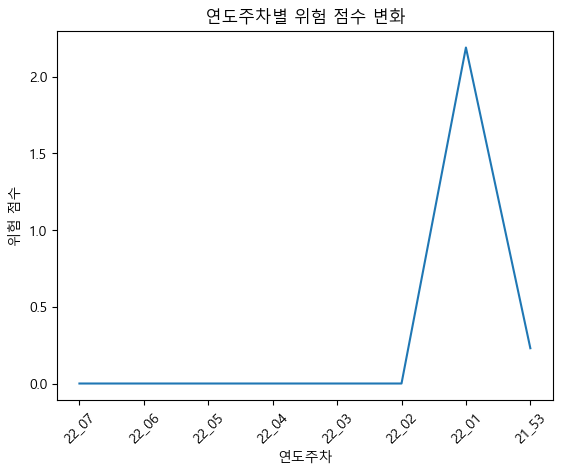

HS Code : 1003902000
      연도주차    단가        신고중량
0    17_04 0.192 3149912.500
1    17_05 0.192 3412412.500
2    17_06 0.192 2054420.000
3    17_07 0.192 1861815.000
4    17_08 0.192  354402.500
..     ...   ...         ...
292  22_34 0.383  183362.562
293  22_35 0.383  183362.562
294  22_36 0.366  116280.000
295  22_37 0.379   75557.500
296  22_38 0.379   75557.500

[297 rows x 3 columns]
22_07주차
22_06주차
22_05주차
22_04주차
22_03주차
22_02주차
22_01주차
21_53주차


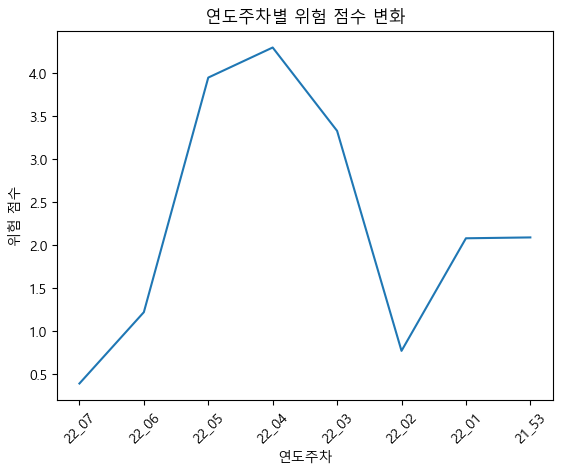

HS Code : 1104230000
      연도주차    단가       신고중량
0    17_04 0.389  38475.125
1    17_05 0.430 166375.125
2    17_06 0.477 415325.600
3    17_07 0.478 462700.475
4    17_08 0.475 537900.475
..     ...   ...        ...
292  22_34 0.451 446502.199
293  22_35 0.448 560500.000
294  22_36 0.447 413250.000
295  22_37 0.465 337250.000
296  22_38 0.473 231750.000

[297 rows x 3 columns]
22_07주차
22_06주차
22_05주차
22_04주차
22_03주차
22_02주차
22_01주차
21_53주차


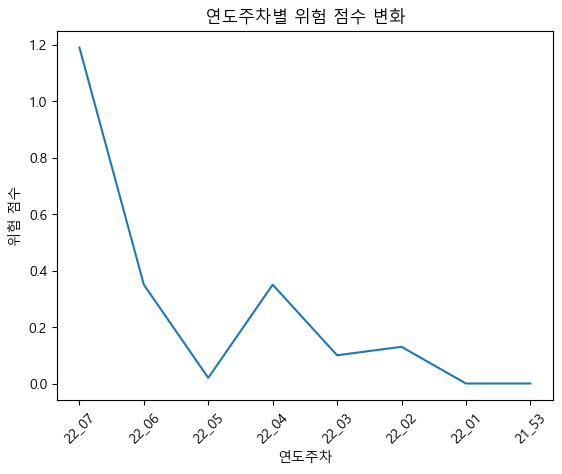

HS Code : 2710121000
      연도주차    단가         신고중량
0    17_04 0.551  2149886.250
1    17_05 0.550  4114309.500
2    17_06 0.549  6381111.750
3    17_07 0.549  4234150.250
4    17_08 0.547  9687853.750
..     ...   ...          ...
292  22_34 0.801 16626932.000
293  22_35 0.955  9728367.250
294  22_36 0.916  8810688.000
295  22_37 0.916  8810688.000
296  22_38 0.713 14231087.750

[297 rows x 3 columns]
22_07주차
22_06주차
22_05주차
22_04주차
22_03주차
22_02주차
22_01주차
21_53주차


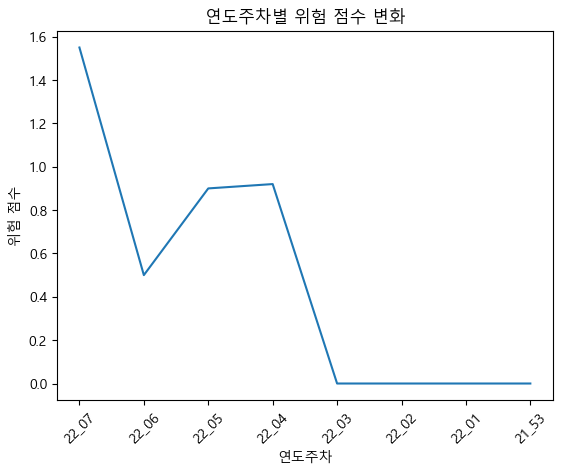

HS Code : 3104200000
      연도주차    단가         신고중량
0    17_04 0.299 11374102.375
1    17_05 0.298 16317880.400
2    17_06 0.291 12415604.100
3    17_07 0.291 10819745.700
4    17_08 0.289 11582318.950
..     ...   ...          ...
292  22_34 0.992 29386228.624
293  22_35 1.007  9666683.242
294  22_36 1.006  9627907.123
295  22_37 1.007  9785683.655
296  22_38 1.010  2767031.598

[297 rows x 3 columns]
22_07주차
22_06주차
22_05주차
22_04주차
22_03주차
22_02주차
22_01주차
21_53주차


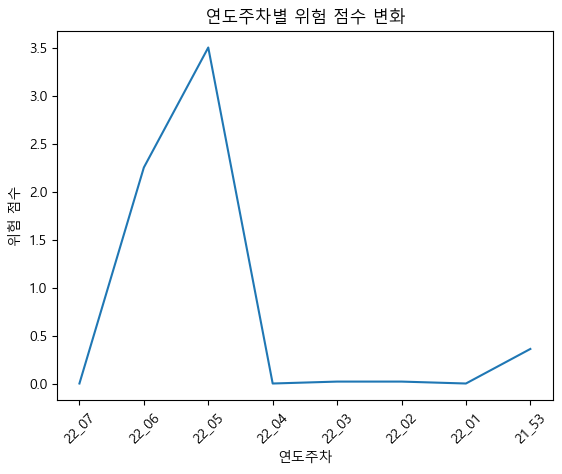

HS Code : 2905172000
      연도주차    단가       신고중량
0    17_04 1.801  49211.300
1    17_05 1.754  65983.925
2    17_06 1.838  79977.625
3    17_07 1.857  61760.131
4    17_08 1.863  63759.256
..     ...   ...        ...
292  22_34 3.054 100640.853
293  22_35 3.011 131752.708
294  22_36 2.871 136344.133
295  22_37 2.882  95667.133
296  22_38 2.817  62904.505

[297 rows x 3 columns]
22_16주차
22_15주차
22_14주차
22_13주차
22_12주차
22_11주차
22_10주차
22_09주차


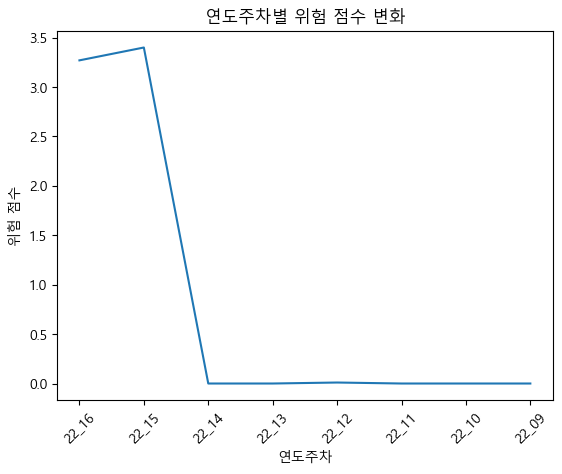

[np.float64(2.95), np.float64(0.92), np.float64(3.34), np.float64(2.17), np.float64(3.32), np.float64(4.72), np.float64(4.9), np.float64(3.1), np.float64(1.28), np.float64(2.19), np.float64(4.3), np.float64(1.19), np.float64(1.55), np.float64(3.5), np.float64(3.4)]
[54, 166, 82, 49, 46, 42, 40, 36, 30, 37, 34, 31, 31, 33, 23]


In [2]:
추출용 = [3102109000,3707901010,4407191000,8111000000,2701129010,2804701000,1511901000,305531000,302140000,1003901000,1003902000,1104230000,2710121000,3104200000,2905172000]
b = [59, 174, 85, 54, 48, 48, 44, 39, 38, 39, 39, 39, 39, 39, 30]

z = []
c = []
e = []
k = []
o = []
z_x = []
z_y = []

for i in range(0, len(추출용)):
  z.append(0) # 품목별 Highest CV를 반영하기 위해 List 생성
  c.append(0) # 품목별 CV값이 임계값 이상인 경우의 횟수를 반영하기 위한 List 생성
  k.append(0) # 임계값을 넘는 횟수
  o.append(0) # 위험경보 여부
  z_x.append(0) # Highest CV의 X값
  z_y.append(0) # Highest CV의 y값

for i in range(0, 8):
  e.append(0) # 품목별 8주간 CV값을 반영하기 위한 List 생성성
  
j = 0

for i in 추출용:
    print(f'HS Code : {i}')
    original[original['HS10단위부호'] == str(i)].sort_values(by = '수리일자', ascending = False)
    data = pd.DataFrame(columns = use_col)
    data = pd.concat([data, original[original['HS10단위부호'] == str(i)]])
    data = data.reset_index(drop=True)

    data = data.sort_values(by='수리일자', ascending=True).reset_index(drop=True)
    
    #
    ## 최근 52주간 수입단가(직전4주평균) 추이 파악
    #
    df_price = data[['연도주차', '과세가격미화금액', '신고중량']]
    df_price_week = df_price.groupby('연도주차')[['과세가격미화금액', '신고중량']].agg(['sum']).reset_index()
    df_price_week.columns = ['연도주차', '과세가격미화금액', '신고중량']


    # 수입이 없는 주차의 값을 0으로 생성
    df_price_week_hole = pd.DataFrame(columns = df_price_week.columns)
    for wk in set(date_index) - set(df_price_week['연도주차'].unique()):
        df_price_week_hole = pd.concat([df_price_week_hole, pd.DataFrame([{'연도주차': wk, '과세가격미화금액': 0, '신고중량': 0}])], ignore_index=True)
    df_price_week_total = pd.concat([df_price_week, df_price_week_hole]).sort_values('연도주차')

    # 해당 주차의 데이터를 직전 4주간 평균으로 대체
    price_w4 = []
    kg_w4 = []
    for x in range(0, len(df_price_week_total) - 3):
        price_w4.append(df_price_week_total[['과세가격미화금액']].iloc[x : x + 4].mean().iloc[0])
        kg_w4.append(df_price_week_total[['신고중량']].iloc[x : x + 4].mean().iloc[0])
    df_price_4w = df_price_week_total[3:]
    df_price_4w['과세가격미화금액'] = price_w4
    df_price_4w['신고중량'] = kg_w4
    df_price_4w = df_price_4w.reset_index(drop = True)
    df_price_4w['과세가격미화금액'] = df_price_4w['과세가격미화금액'].replace(0, np.nan).ffill()
    df_price_4w['신고중량'] = df_price_4w['신고중량'].replace(0, np.nan).ffill()
    df_price_4w['단가'] = df_price_4w['과세가격미화금액'] / df_price_4w['신고중량']
    df_price_4w = df_price_4w[['연도주차', '단가', '신고중량']]
    print(df_price_4w)

    for l in range(b[j]-8,b[j]):

        print(df_price_4w['연도주차'].iloc[-1-l] + '주차')
        #=================== 단가 percertile 구하기 ====================
        data_mean = df_price_4w.iloc[p_eriod-l:-l]['단가'].mean()
        data_std = df_price_4w.iloc[p_eriod-l:-l]['단가'].std()
        stand_quant = (df_price_4w.iloc[-1-l]['단가'] - data_mean) / data_std
        y=np.exp((scipy.stats.norm.cdf(stand_quant)*100 - 95)*np.log(5)/5)

        #=================== 신고중량 percertile 구하기 ====================
        
        ecdf = ECDF(df_price_4w['신고중량'].iloc[p_eriod-l:-l])
        if(ecdf(df_price_4w['신고중량'].iloc[-1-l])>0.5):
            x=np.exp((ecdf(df_price_4w['신고중량'].iloc[-1-l])*100 - 95)*np.log(5)/5)
        else:
            x=np.exp(((1-ecdf(df_price_4w['신고중량'].iloc[-1-l]))*100 - 95)*np.log(5)/5)
        
        e[(l-b[j]+8)] = round(2/(1/y+1/x), 2)
        if(round(2/(1/y+1/x), 2)>1.85):
            k[j] += 1
        if(z[j] < round(2/(1/y+1/x), 2)):
            z[j] = round(2/(1/y+1/x), 2)
            c[j] = l
            
        if(z_x[j] < x):
            z_x[j] = x
            
        if(z_y[j] < y):
            z_y[j] = y      
      
    if(z[j]>1.85):
        o[j] = 1 
    import matplotlib.font_manager as fm

    plt.rc('font', family='Malgun Gothic')  # Windows (맑은 고딕)
    plt.rc('axes', unicode_minus=False)  # 마이너스(-) 기호 깨짐 방지
    
    x_labels = [df_price_4w['연도주차'].iloc[-1-l] for l in range(b[j]-8,b[j])]  # x축 라벨 생성
    plt.plot(x_labels, e)  # x축을 연도주차 값으로 설정
    plt.xticks(rotation=45)  # x축 라벨 회전 (가독성 개선)
    plt.xlabel("연도주차")  # x축 제목 추가
    plt.ylabel("위험 점수")  # y축 제목 추가
    plt.title("연도주차별 위험 점수 변화")  # 그래프 제목 추가
    plt.show()
    
    j += 1
print(z)
print(c)


# 구글드라이브에 있는 엑셀 파일을 불러와서 점수결과 저장하기
collect = pd.read_excel('c:\python\Compare_Models.xlsx', sheet_name="점수")
collect = pd.DataFrame(collect)
collect.loc[:14, 'Model28(1)'] = o
collect.loc[15, 'Model28(1)'] = np.sum(o)
collect.loc[:14, 'Model28(2)'] = z
collect.loc[15, 'Model28(2)'] = np.mean(z)
collect.to_excel('c:\python\Compare_Models.xlsx', sheet_name="점수", index=False)

collect1 = pd.read_excel('c:\python\Collectroc(t).xlsx', sheet_name="점수")
collect1 = pd.DataFrame(collect1)
collect1.loc[:14, 'y_scores[29]'] = z
collect1.to_excel('c:\python\Collectroc(t).xlsx', sheet_name="점수", index=False)

collect2 = pd.read_excel('c:\python\Collectroc(x).xlsx', sheet_name="점수")
collect2 = pd.DataFrame(collect2)
collect2.loc[:14, 'y_scores[29]'] = z_x
collect2.to_excel('c:\python\Collectroc(x).xlsx', sheet_name="점수", index=False)

collect3 = pd.read_excel('c:\python\Collectroc(y).xlsx', sheet_name="점수")
collect3 = pd.DataFrame(collect3)
collect3.loc[:14, 'y_scores[29]'] = z_y
collect3.to_excel('c:\python\Collectroc(y).xlsx', sheet_name="점수", index=False)

HS Code : 3926909000
21_49주차
21_48주차
21_47주차
21_46주차
21_45주차
21_44주차
21_43주차
21_42주차


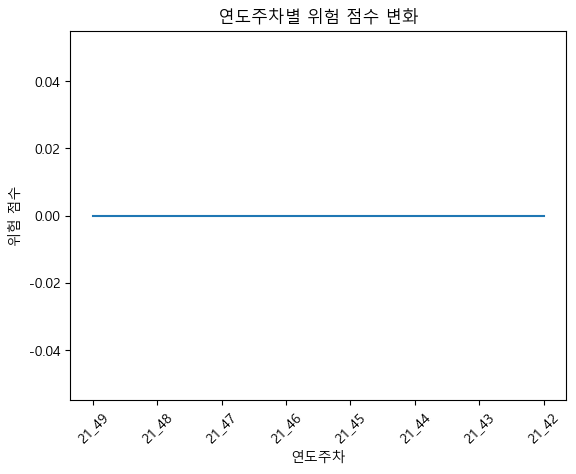

HS Code : 7326909000
21_49주차
21_48주차
21_47주차
21_46주차
21_45주차
21_44주차
21_43주차
21_42주차


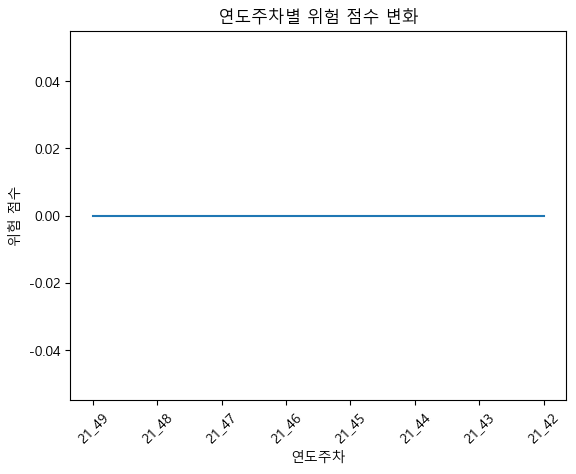

HS Code : 8708999000
21_49주차
21_48주차
21_47주차
21_46주차
21_45주차
21_44주차
21_43주차
21_42주차


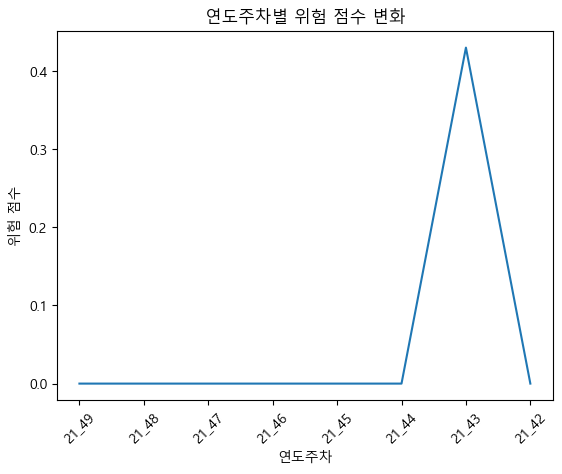

HS Code : 2106909099
21_49주차
21_48주차
21_47주차
21_46주차
21_45주차
21_44주차
21_43주차
21_42주차


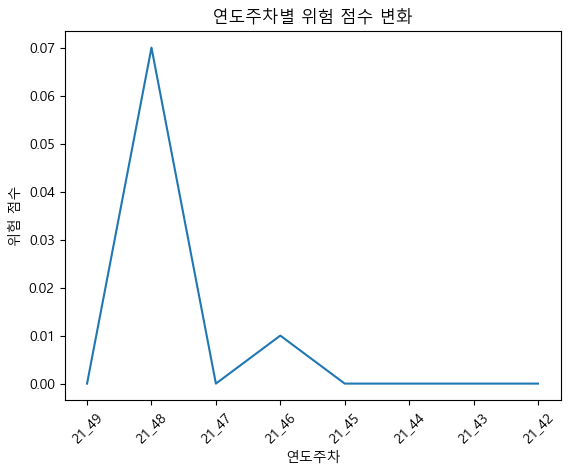

HS Code : 4911990000
21_49주차
21_48주차
21_47주차
21_46주차
21_45주차
21_44주차
21_43주차
21_42주차


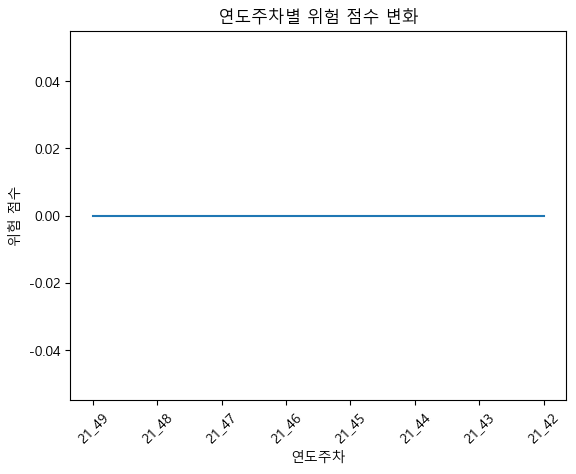

HS Code : 6403999000
21_49주차
21_48주차
21_47주차
21_46주차
21_45주차
21_44주차
21_43주차
21_42주차


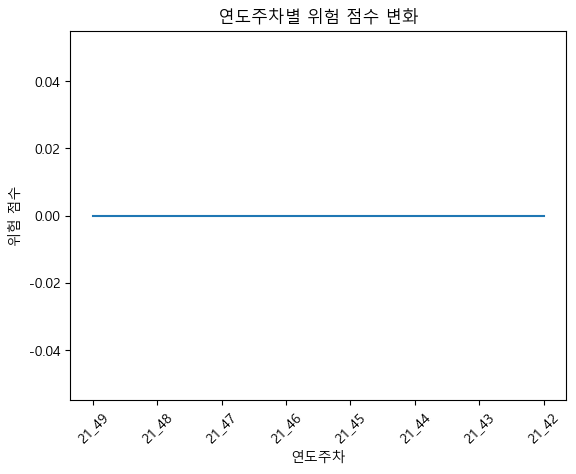

HS Code : 9031809099
21_49주차
21_48주차
21_47주차
21_46주차
21_45주차
21_44주차
21_43주차
21_42주차


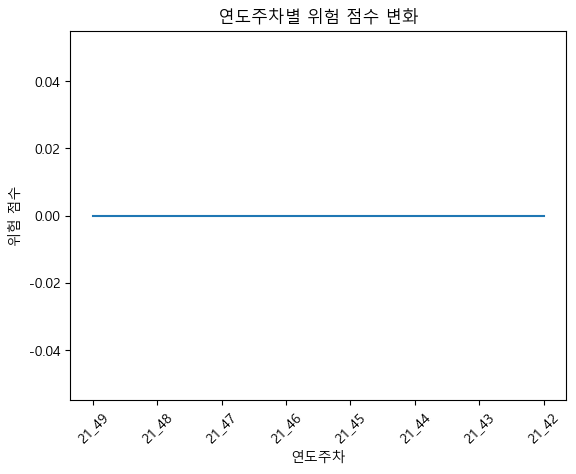

HS Code : 8542391000
21_49주차
21_48주차
21_47주차
21_46주차
21_45주차
21_44주차
21_43주차
21_42주차


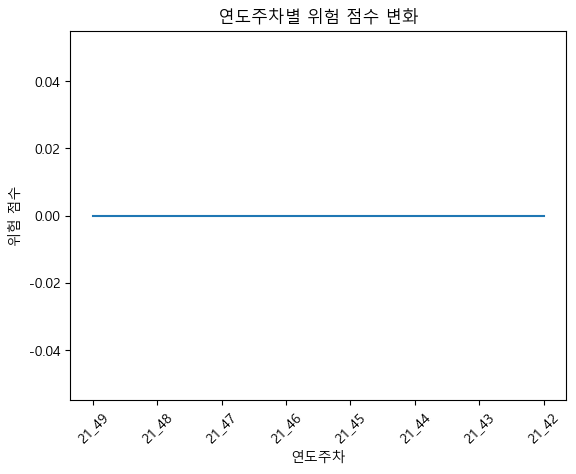

HS Code : 6109101000
21_49주차
21_48주차
21_47주차
21_46주차
21_45주차
21_44주차
21_43주차
21_42주차


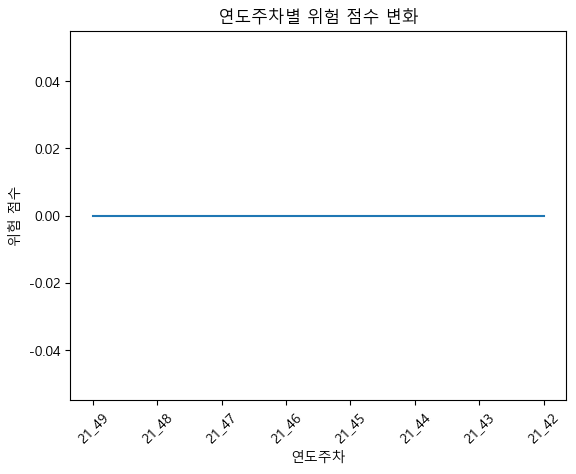

HS Code : 2934996000
21_49주차
21_48주차
21_47주차
21_46주차
21_45주차
21_44주차
21_43주차
21_42주차


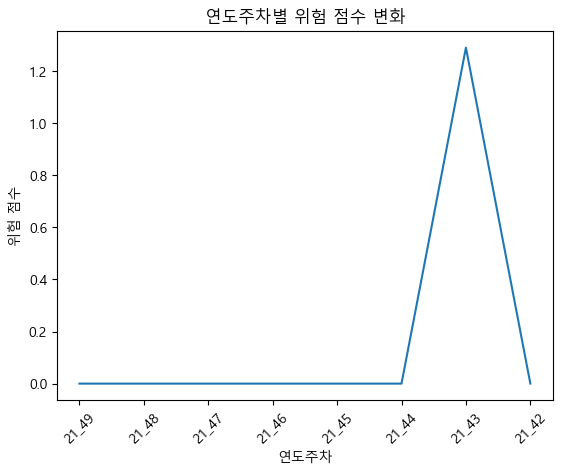

HS Code : 4016930000
21_49주차
21_48주차
21_47주차
21_46주차
21_45주차
21_44주차
21_43주차
21_42주차


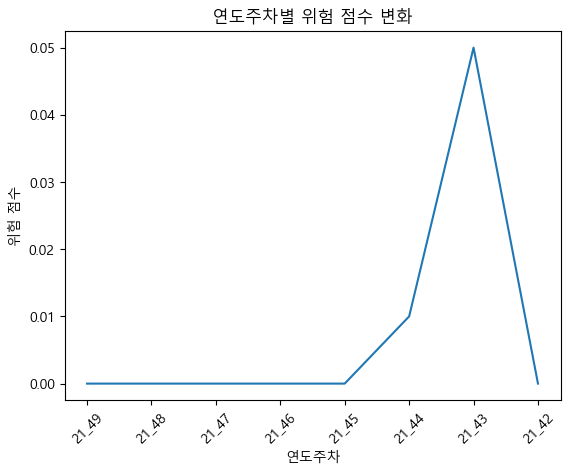

HS Code : 6110200000
21_49주차
21_48주차
21_47주차
21_46주차
21_45주차
21_44주차
21_43주차
21_42주차


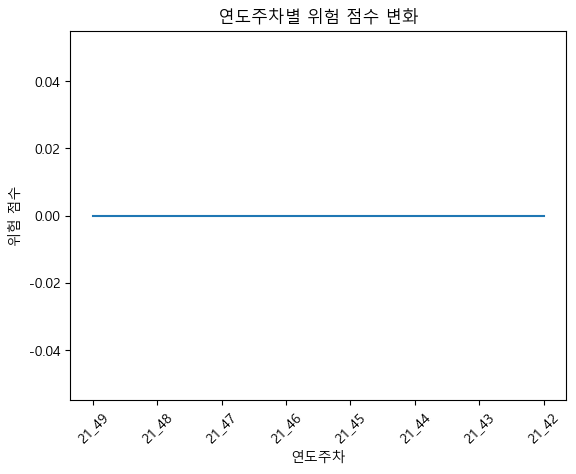

HS Code : 6211499000
21_49주차
21_48주차
21_47주차
21_46주차
21_45주차
21_44주차
21_43주차
21_42주차


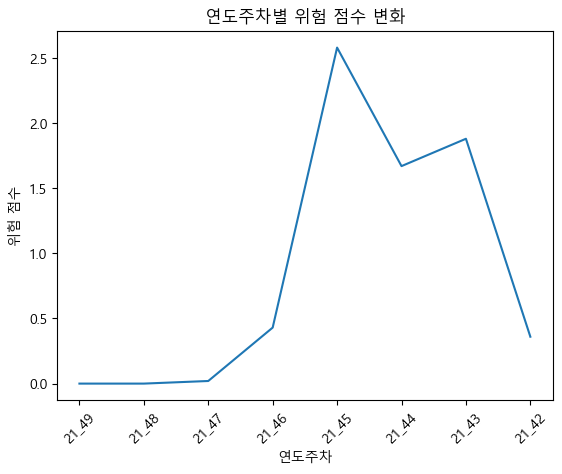

HS Code : 4202999000
21_49주차
21_48주차
21_47주차
21_46주차
21_45주차
21_44주차
21_43주차
21_42주차


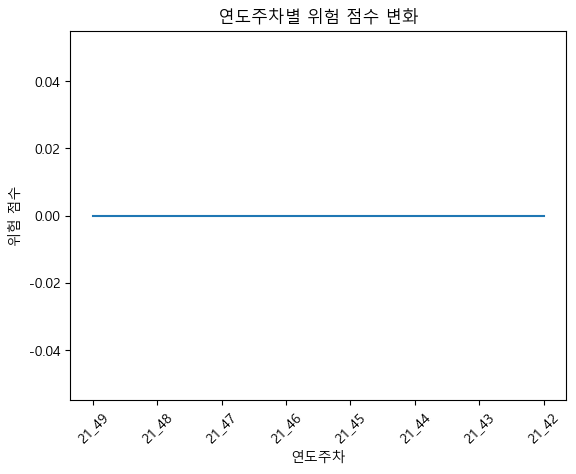

HS Code : 3304991000
21_49주차
21_48주차
21_47주차
21_46주차
21_45주차
21_44주차
21_43주차
21_42주차


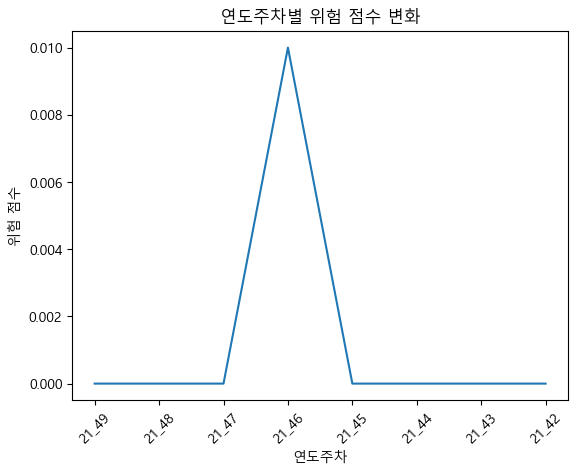

HS Code : 8544429090
21_49주차
21_48주차
21_47주차
21_46주차
21_45주차
21_44주차
21_43주차
21_42주차


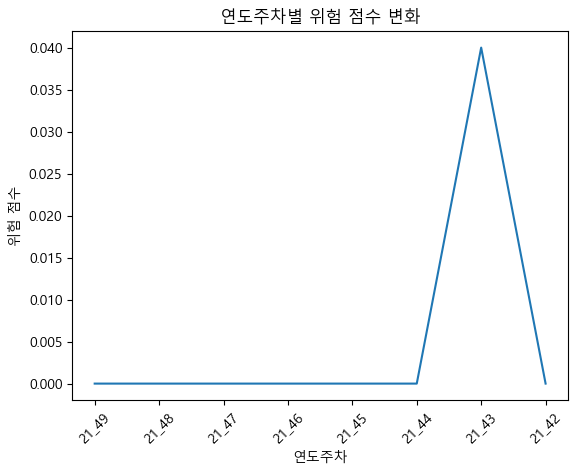

HS Code : 8481801090
21_49주차
21_48주차
21_47주차
21_46주차
21_45주차
21_44주차
21_43주차
21_42주차


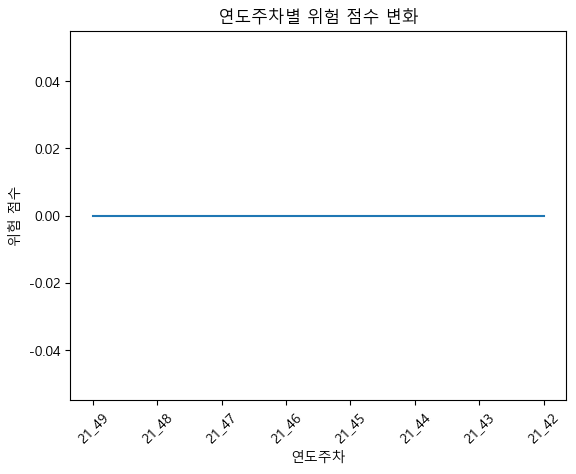

HS Code : 3304999000
21_49주차
21_48주차
21_47주차
21_46주차
21_45주차
21_44주차
21_43주차
21_42주차


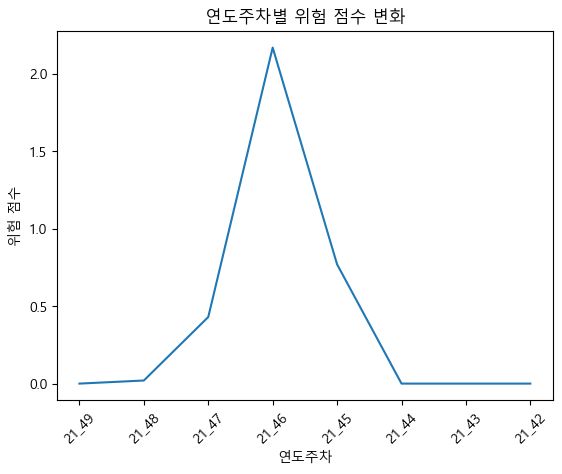

HS Code : 8543709090
21_49주차
21_48주차
21_47주차
21_46주차
21_45주차
21_44주차
21_43주차
21_42주차


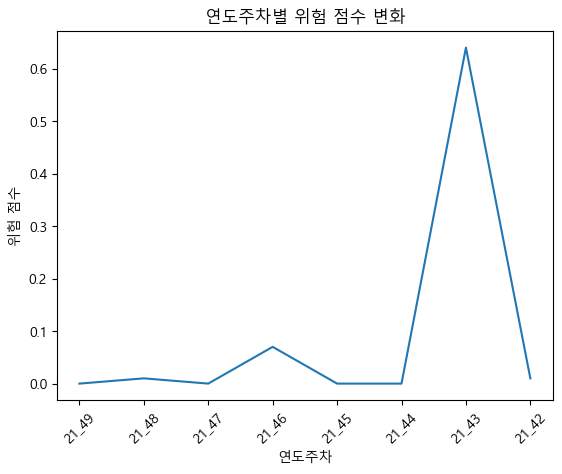

HS Code : 6404199000
21_49주차
21_48주차
21_47주차
21_46주차
21_45주차
21_44주차
21_43주차
21_42주차


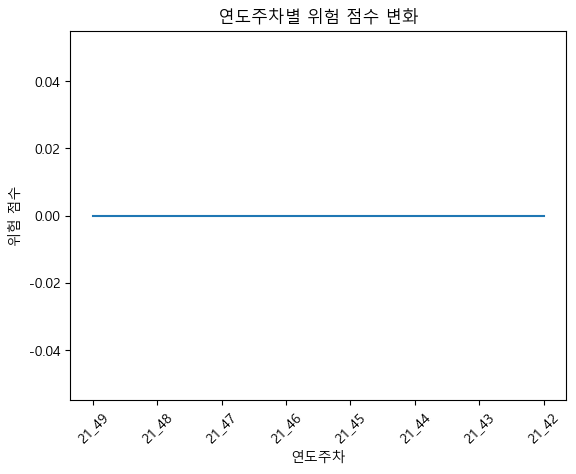

HS Code : 3004909900
21_49주차
21_48주차
21_47주차
21_46주차
21_45주차
21_44주차
21_43주차
21_42주차


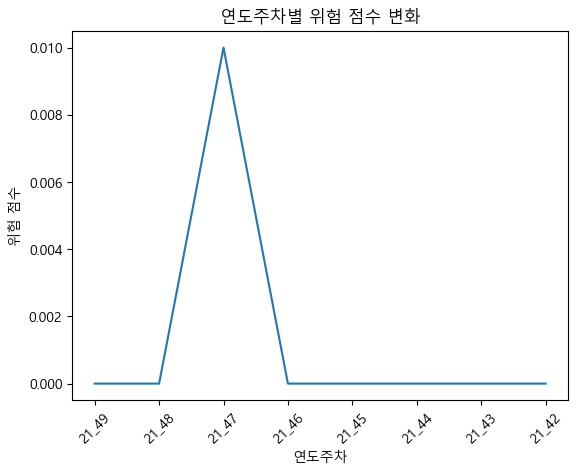

HS Code : 8542311000
21_49주차
21_48주차
21_47주차
21_46주차
21_45주차
21_44주차
21_43주차
21_42주차


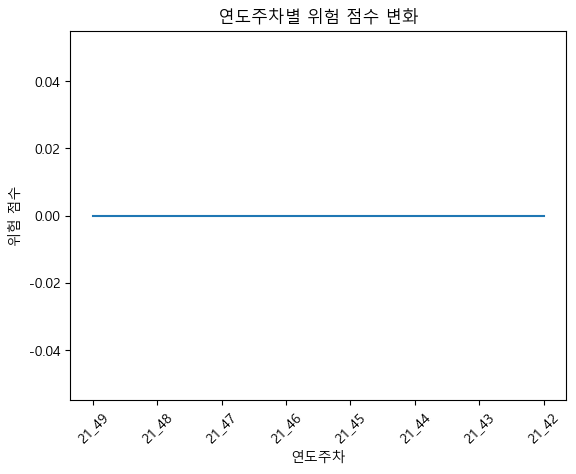

HS Code : 4901999000
21_49주차
21_48주차
21_47주차
21_46주차
21_45주차
21_44주차
21_43주차
21_42주차


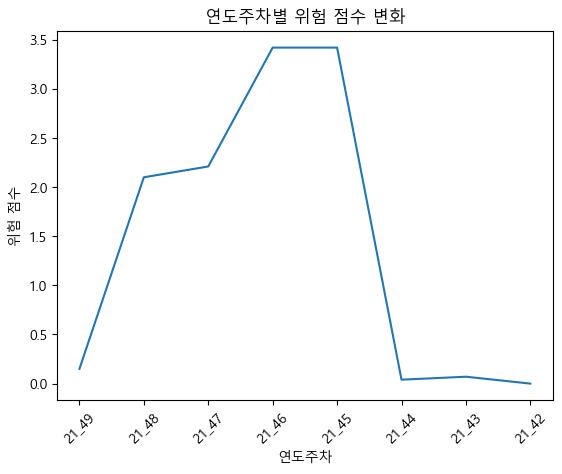

HS Code : 8473309090
21_49주차
21_48주차
21_47주차
21_46주차
21_45주차
21_44주차
21_43주차
21_42주차


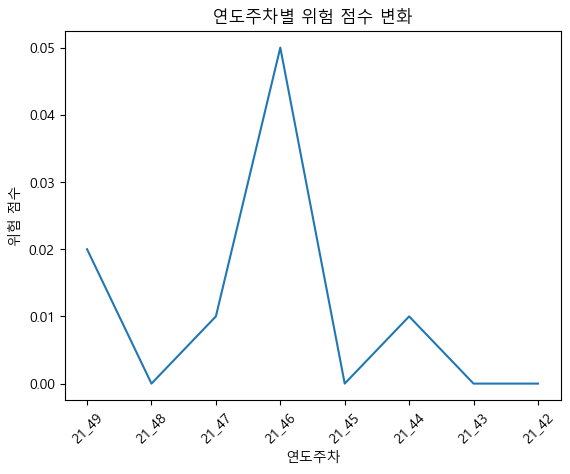

HS Code : 6307909000
21_49주차
21_48주차
21_47주차
21_46주차
21_45주차
21_44주차
21_43주차
21_42주차


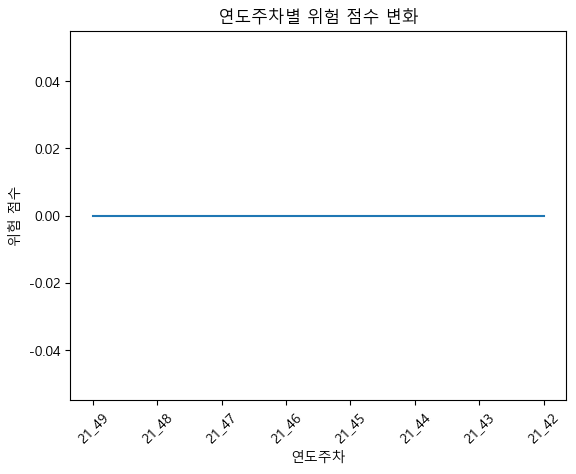

HS Code : 4202211090
21_49주차
21_48주차
21_47주차
21_46주차
21_45주차
21_44주차
21_43주차
21_42주차


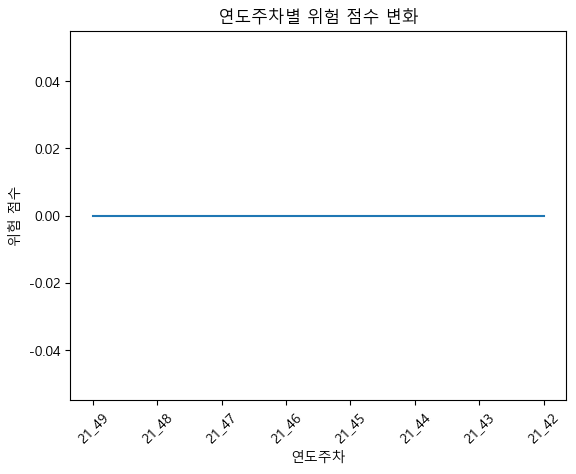

HS Code : 8536509090
21_49주차
21_48주차
21_47주차
21_46주차
21_45주차
21_44주차
21_43주차
21_42주차


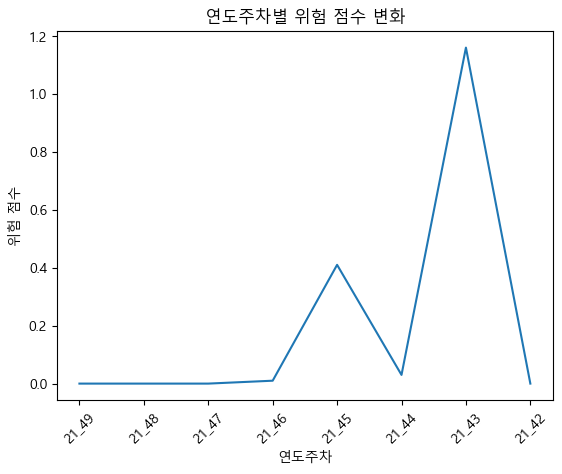

HS Code : 8538909000
21_49주차
21_48주차
21_47주차
21_46주차
21_45주차
21_44주차
21_43주차
21_42주차


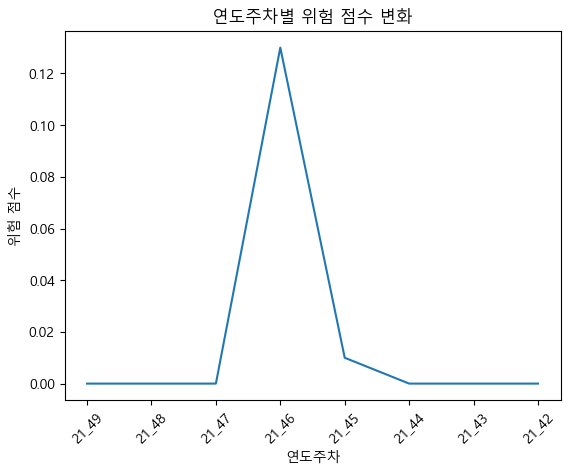

HS Code : 8479909090
21_49주차
21_48주차
21_47주차
21_46주차
21_45주차
21_44주차
21_43주차
21_42주차


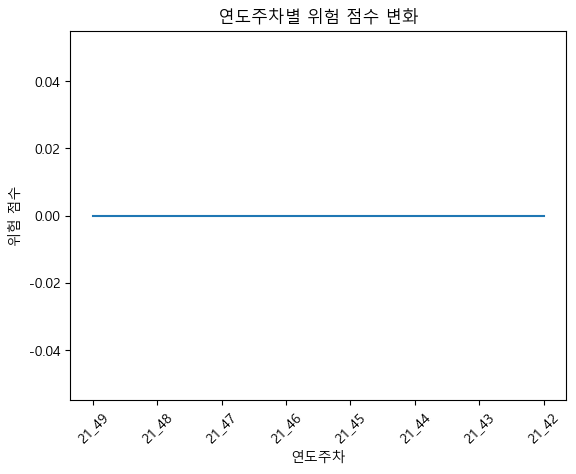

HS Code : 8504409099
21_49주차
21_48주차
21_47주차
21_46주차
21_45주차
21_44주차
21_43주차
21_42주차


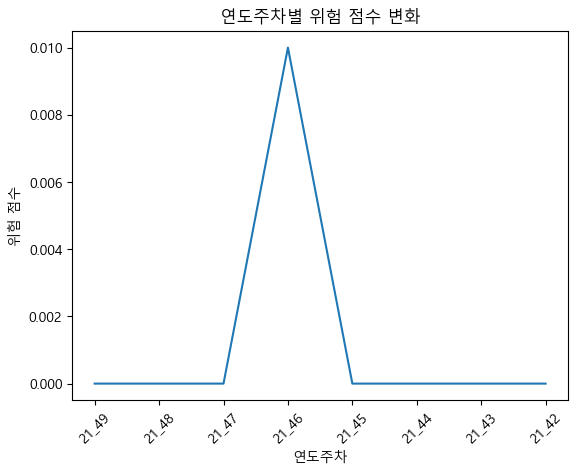

HS Code : 6110909000
21_49주차
21_48주차
21_47주차
21_46주차
21_45주차
21_44주차
21_43주차
21_42주차


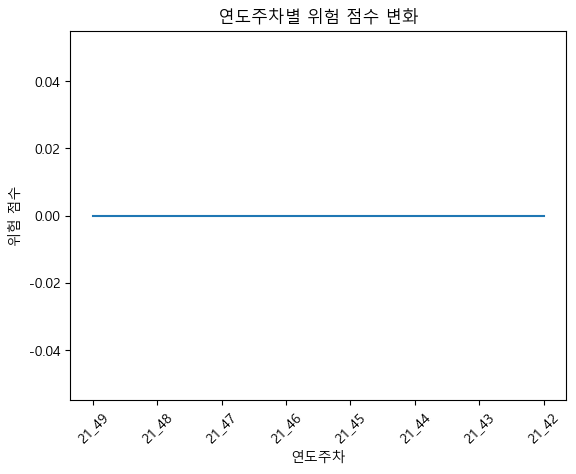

HS Code : 3923100000
21_49주차
21_48주차
21_47주차
21_46주차
21_45주차
21_44주차
21_43주차
21_42주차


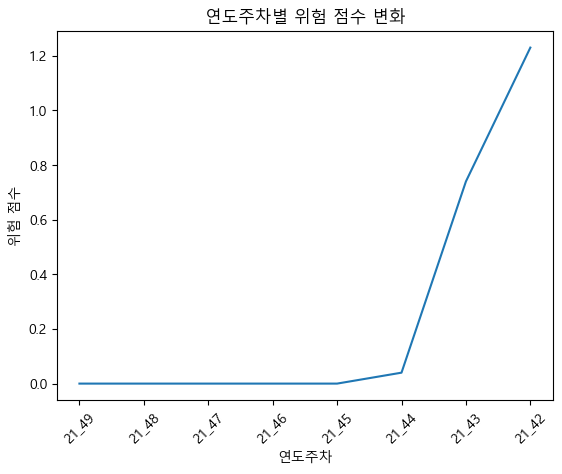

HS Code : 8544422090
21_49주차
21_48주차
21_47주차
21_46주차
21_45주차
21_44주차
21_43주차
21_42주차


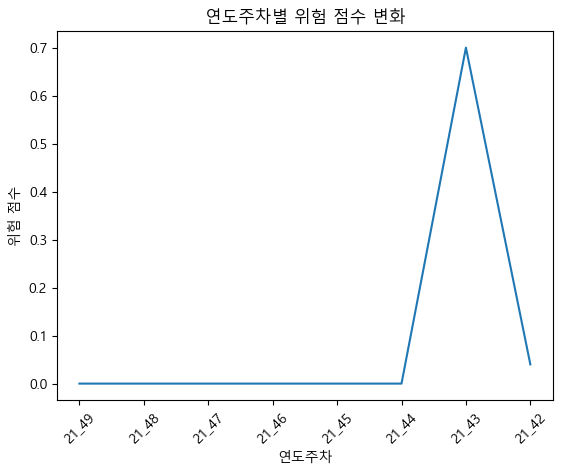

HS Code : 8537109000
21_49주차
21_48주차
21_47주차
21_46주차
21_45주차
21_44주차
21_43주차
21_42주차


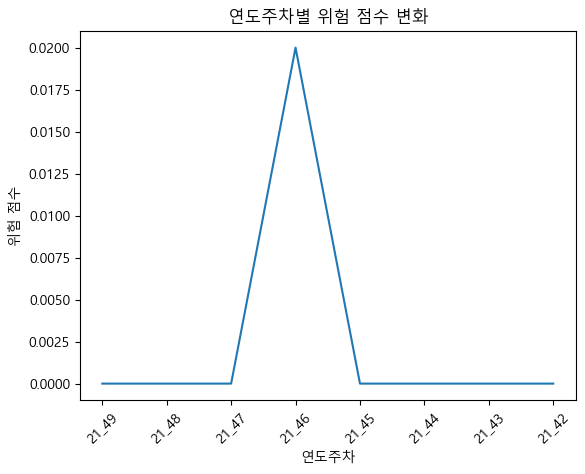

HS Code : 8536699000
21_49주차
21_48주차
21_47주차
21_46주차
21_45주차
21_44주차
21_43주차
21_42주차


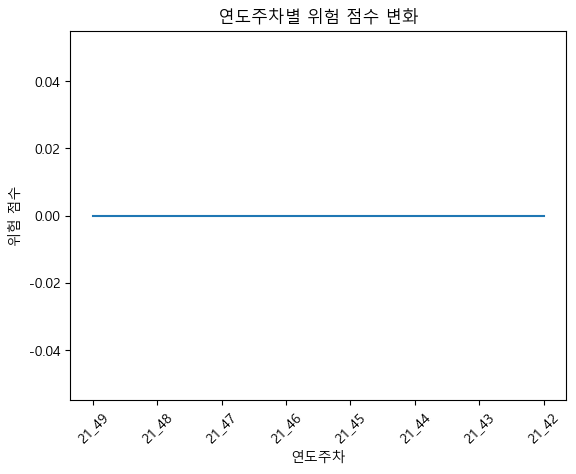

HS Code : 3102109000
21_14주차
21_13주차
21_12주차
21_11주차
21_10주차
21_09주차
21_08주차
21_07주차


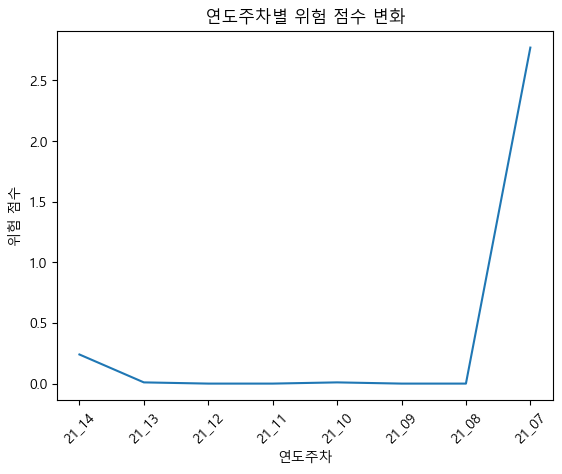

HS Code : 3707901010
19_04주차
19_03주차
19_02주차
19_01주차
18_52주차
18_51주차
18_50주차
18_49주차


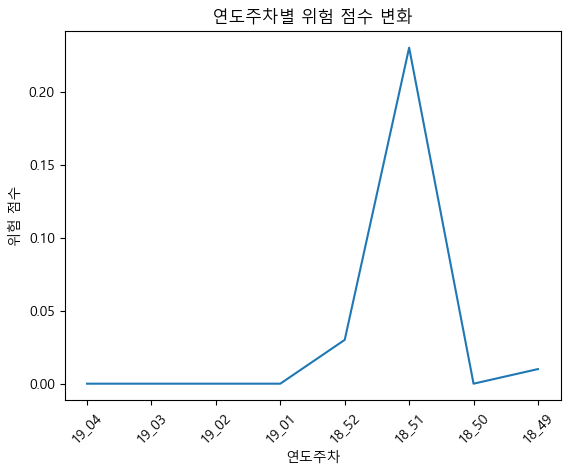

HS Code : 4407191000
20_41주차
20_40주차
20_39주차
20_38주차
20_37주차
20_36주차
20_35주차
20_34주차


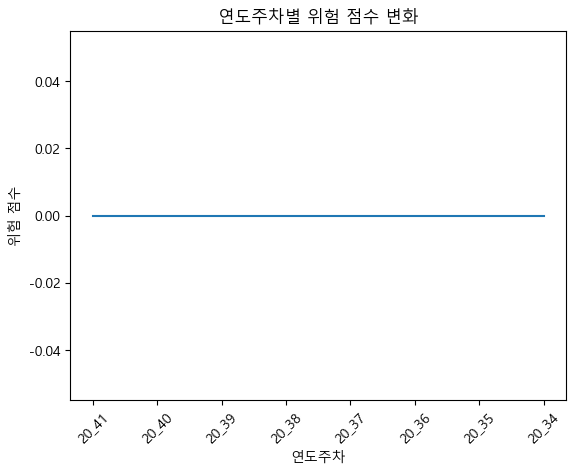

HS Code : 8111000000
21_19주차
21_18주차
21_17주차
21_16주차
21_15주차
21_14주차
21_13주차
21_12주차


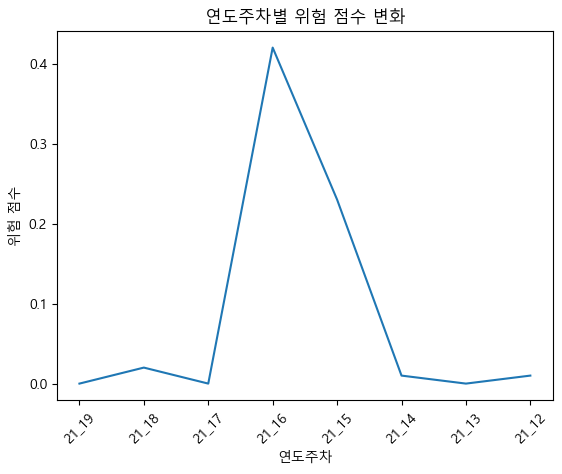

HS Code : 2701129010
21_25주차
21_24주차
21_23주차
21_22주차
21_21주차
21_20주차
21_19주차
21_18주차


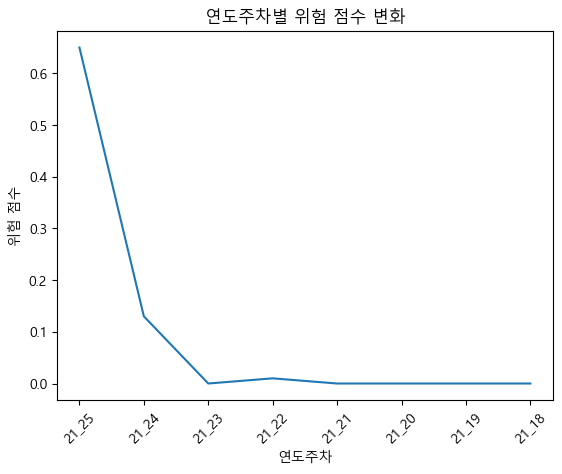

HS Code : 2804701000
21_25주차
21_24주차
21_23주차
21_22주차
21_21주차
21_20주차
21_19주차
21_18주차


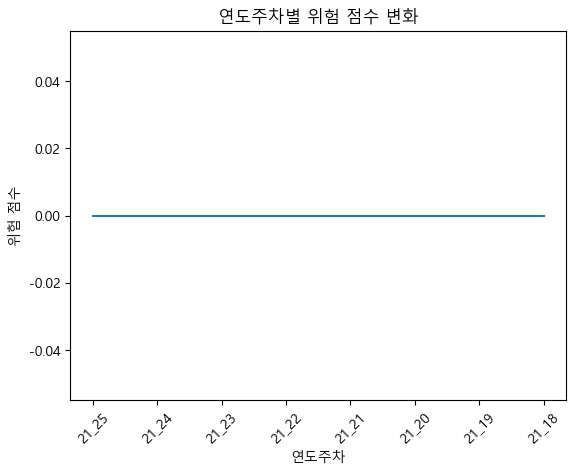

HS Code : 1511901000
21_29주차
21_28주차
21_27주차
21_26주차
21_25주차
21_24주차
21_23주차
21_22주차


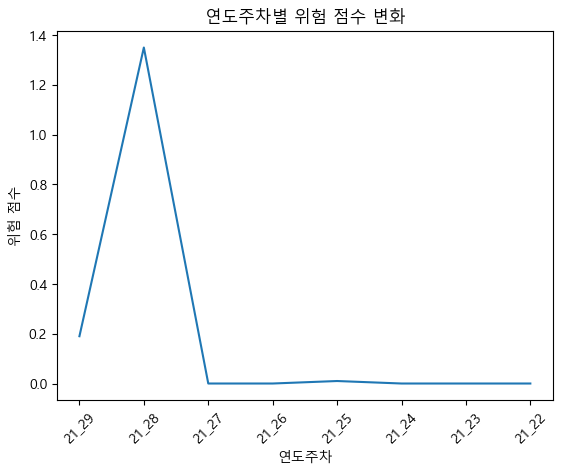

HS Code : 305531000
21_34주차
21_33주차
21_32주차
21_31주차
21_30주차
21_29주차
21_28주차
21_27주차


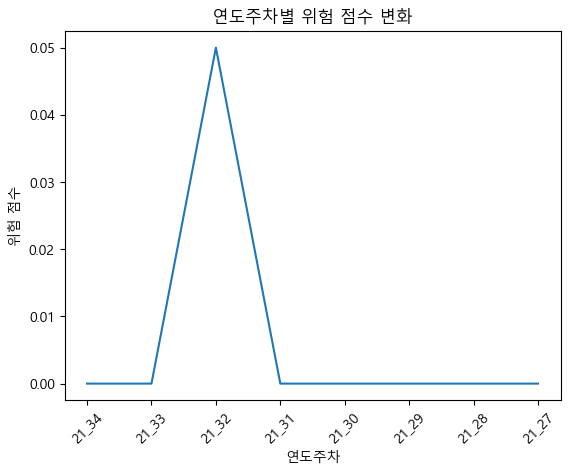

HS Code : 302140000
21_35주차
21_34주차
21_33주차
21_32주차
21_31주차
21_30주차
21_29주차
21_28주차


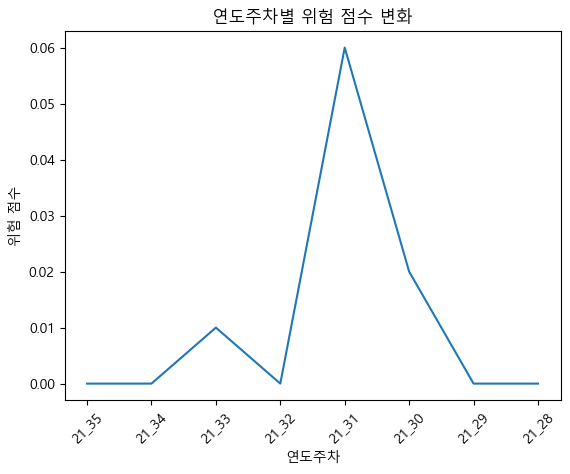

HS Code : 1003901000
21_34주차
21_33주차
21_32주차
21_31주차
21_30주차
21_29주차
21_28주차
21_27주차


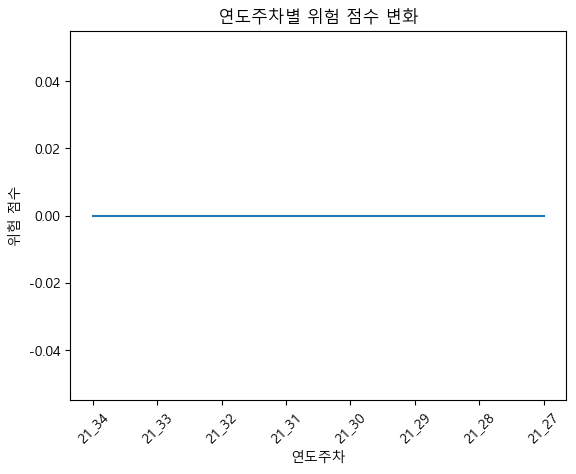

HS Code : 1003902000
21_34주차
21_33주차
21_32주차
21_31주차
21_30주차
21_29주차
21_28주차
21_27주차


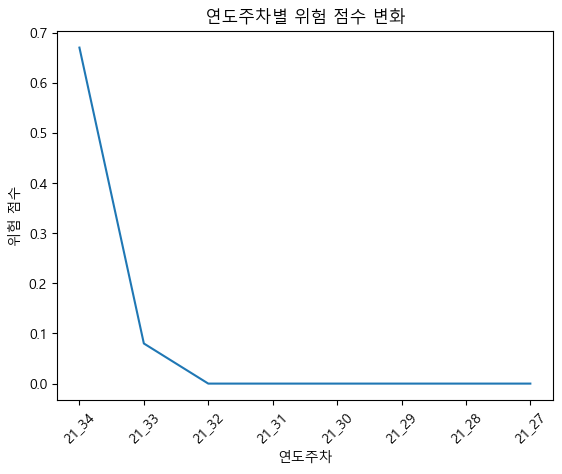

HS Code : 1104230000
21_34주차
21_33주차
21_32주차
21_31주차
21_30주차
21_29주차
21_28주차
21_27주차


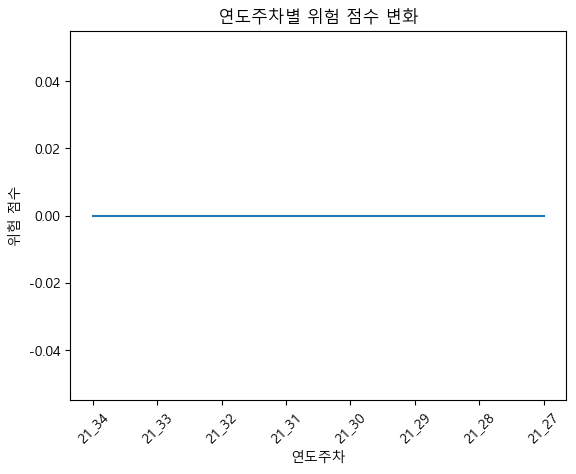

HS Code : 2710121000
21_34주차
21_33주차
21_32주차
21_31주차
21_30주차
21_29주차
21_28주차
21_27주차


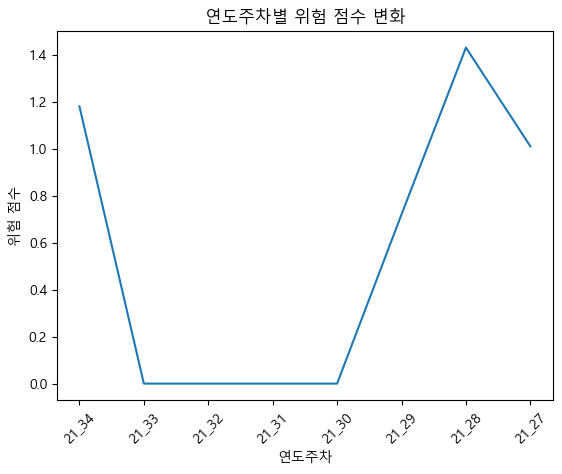

HS Code : 3104200000
21_34주차
21_33주차
21_32주차
21_31주차
21_30주차
21_29주차
21_28주차
21_27주차


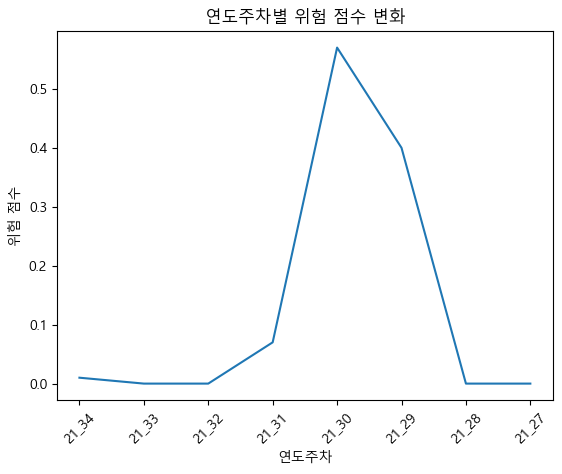

HS Code : 2905172000
21_43주차
21_42주차
21_41주차
21_40주차
21_39주차
21_38주차
21_37주차
21_36주차


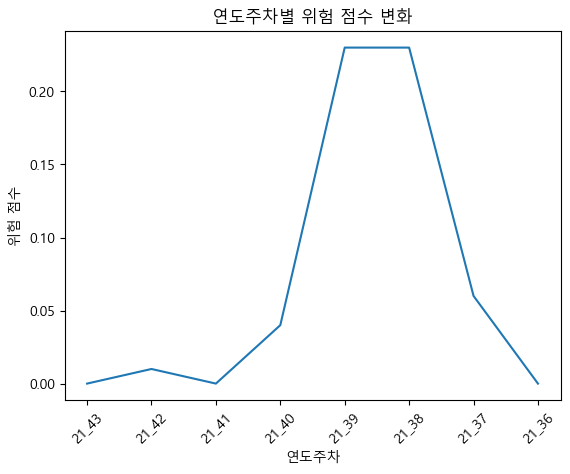

[0, 0, np.float64(0.43), np.float64(0.07), 0, 0, 0, 0, 0, np.float64(1.29), np.float64(0.05), 0, np.float64(2.58), 0, np.float64(0.01), np.float64(0.04), 0, np.float64(2.17), np.float64(0.64), 0, np.float64(0.01), 0, np.float64(3.42), np.float64(0.05), 0, 0, np.float64(1.16), np.float64(0.13), 0, np.float64(0.01), 0, np.float64(1.23), np.float64(0.7), np.float64(0.02), 0, np.float64(2.77), np.float64(0.23), 0, np.float64(0.42), np.float64(0.65), 0, np.float64(1.35), np.float64(0.05), np.float64(0.06), 0, np.float64(0.67), 0, np.float64(1.43), np.float64(0.57), np.float64(0.23)]
[0, 0, 48, 43, 0, 0, 0, 0, 0, 48, 48, 0, 46, 0, 45, 48, 0, 45, 48, 0, 44, 0, 45, 45, 0, 0, 48, 45, 0, 45, 0, 49, 48, 45, 0, 84, 197, 0, 75, 66, 0, 63, 59, 60, 0, 57, 0, 63, 61, 52]


In [3]:
리스트 = pd.read_excel('c:\python\list(m).xlsx')
추출용 = 리스트.iloc[:,0].tolist()
리스트 = pd.read_excel('c:\python\list(m1).xlsx')
b = 리스트.iloc[:,0].tolist()

z = []
c = []
e = []
k = []
o = []
z_x = []
z_y = []

for i in range(0, len(추출용)):
  z.append(0) # 품목별 Highest CV를 반영하기 위해 List 생성
  c.append(0) # 품목별 CV값이 임계값 이상인 경우의 횟수를 반영하기 위한 List 생성
  k.append(0) # 임계값을 넘는 횟수
  o.append(0) # 위험경보 여부
  z_x.append(0) # Highest CV의 X값
  z_y.append(0) # Highest CV의 y값

for i in range(0, 8):
  e.append(0) # 품목별 8주간 CV값을 반영하기 위한 List 생성성
  
j = 0

for i in 추출용:
    print(f'HS Code : {i}')
    original[original['HS10단위부호'] == str(i)].sort_values(by = '수리일자', ascending = False)
    data = pd.DataFrame(columns = use_col)
    data = pd.concat([data, original[original['HS10단위부호'] == str(i)]])
    data = data.reset_index(drop=True)

    data = data.sort_values(by='수리일자', ascending=True).reset_index(drop=True)
    
    #
    ## 최근 52주간 수입단가(직전4주평균) 추이 파악
    #
    df_price = data[['연도주차', '과세가격미화금액', '신고중량']]
    df_price_week = df_price.groupby('연도주차')[['과세가격미화금액', '신고중량']].agg(['sum']).reset_index()
    df_price_week.columns = ['연도주차', '과세가격미화금액', '신고중량']


    # 수입이 없는 주차의 값을 0으로 생성
    df_price_week_hole = pd.DataFrame(columns = df_price_week.columns)
    for wk in set(date_index) - set(df_price_week['연도주차'].unique()):
        df_price_week_hole = pd.concat([df_price_week_hole, pd.DataFrame([{'연도주차': wk, '과세가격미화금액': 0, '신고중량': 0}])], ignore_index=True)
    df_price_week_total = pd.concat([df_price_week, df_price_week_hole]).sort_values('연도주차')

    # 해당 주차의 데이터를 직전 4주간 평균으로 대체
    price_w4 = []
    kg_w4 = []
    for x in range(0, len(df_price_week_total) - 3):
        price_w4.append(df_price_week_total[['과세가격미화금액']].iloc[x : x + 4].mean().iloc[0])
        kg_w4.append(df_price_week_total[['신고중량']].iloc[x : x + 4].mean().iloc[0])
    df_price_4w = df_price_week_total[3:]
    df_price_4w['과세가격미화금액'] = price_w4
    df_price_4w['신고중량'] = kg_w4
    df_price_4w = df_price_4w.reset_index(drop = True)
    df_price_4w['과세가격미화금액'] = df_price_4w['과세가격미화금액'].replace(0, np.nan).ffill()
    df_price_4w['신고중량'] = df_price_4w['신고중량'].replace(0, np.nan).ffill()
    df_price_4w['단가'] = df_price_4w['과세가격미화금액'] / df_price_4w['신고중량']
    df_price_4w = df_price_4w[['연도주차', '단가', '신고중량']]

    for l in range(b[j]-8,b[j]):

        print(df_price_4w['연도주차'].iloc[-1-l] + '주차')
        #=================== 단가 percertile 구하기 ====================
        data_mean = df_price_4w.iloc[p_eriod-l:-l]['단가'].mean()
        data_std = df_price_4w.iloc[p_eriod-l:-l]['단가'].std()
        stand_quant = (df_price_4w.iloc[-1-l]['단가'] - data_mean) / data_std
        y=np.exp((scipy.stats.norm.cdf(stand_quant)*100 - 95)*np.log(5)/5)

        #=================== 신고중량 percertile 구하기 ====================
        
        ecdf = ECDF(df_price_4w['신고중량'].iloc[p_eriod-l:-l])
        if(ecdf(df_price_4w['신고중량'].iloc[-1-l])>0.5):
            x=np.exp((ecdf(df_price_4w['신고중량'].iloc[-1-l])*100 - 95)*np.log(5)/5)
        else:
            x=np.exp(((1-ecdf(df_price_4w['신고중량'].iloc[-1-l]))*100 - 95)*np.log(5)/5)
        
        e[(l-b[j]+8)] = round(2/(1/y+1/x), 2)
        if(round(2/(1/y+1/x), 2)>1.85):
            k[j] += 1
        if(z[j] < round(2/(1/y+1/x), 2)):
            z[j] = round(2/(1/y+1/x), 2)
            c[j] = l
        
        if(z_x[j] < x):
            z_x[j] = x
            
        if(z_y[j] < y):
            z_y[j] = y      
      
    if(z[j]<1.85):
        o[j] = 1
 
    import matplotlib.font_manager as fm

    plt.rc('font', family='Malgun Gothic')  # Windows (맑은 고딕)
    plt.rc('axes', unicode_minus=False)  # 마이너스(-) 기호 깨짐 방지
    
    x_labels = [df_price_4w['연도주차'].iloc[-1-l] for l in range(b[j]-8,b[j])]  # x축 라벨 생성
    plt.plot(x_labels, e)  # x축을 연도주차 값으로 설정
    plt.xticks(rotation=45)  # x축 라벨 회전 (가독성 개선)
    plt.xlabel("연도주차")  # x축 제목 추가
    plt.ylabel("위험 점수")  # y축 제목 추가
    plt.title("연도주차별 위험 점수 변화")  # 그래프 제목 추가
    plt.show()
    
    j += 1
print(z)
print(c)

# 구글드라이브에 있는 엑셀 파일을 불러와서 점수결과 저장하기
collect = pd.read_excel('c:\python\Compare_Models50.xlsx', sheet_name="점수")
collect = pd.DataFrame(collect)
collect.loc[:49, 'Model28(1)'] = o
collect.loc[50, 'Model28(1)'] = np.sum(o)
collect.loc[:49, 'Model28(2)'] = z
collect.loc[50, 'Model28(2)'] = np.mean(z)
collect.to_excel('c:\python\Compare_Models50.xlsx', sheet_name="점수", index=False)

collect1 = pd.read_excel('c:\python\Collectroc(t).xlsx', sheet_name="점수")
collect1 = pd.DataFrame(collect1)
collect1.loc[15:65, 'y_scores[29]'] = z
collect1.to_excel('c:\python\Collectroc(t).xlsx', sheet_name="점수", index=False)

collect2 = pd.read_excel('c:\python\Collectroc(x).xlsx', sheet_name="점수")
collect2 = pd.DataFrame(collect2)
collect2.loc[15:65, 'y_scores[29]'] = z_x
collect2.to_excel('c:\python\Collectroc(x).xlsx', sheet_name="점수", index=False)

collect3 = pd.read_excel('c:\python\Collectroc(y).xlsx', sheet_name="점수")
collect3 = pd.DataFrame(collect3)
collect3.loc[15:65, 'y_scores[29]'] = z_y
collect3.to_excel('c:\python\Collectroc(y).xlsx', sheet_name="점수", index=False)